In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import RocCurveDisplay

In [54]:
data=pd.read_csv('HR_comma_sep.csv')

In [55]:
data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### **Perform data quality checks by checking for missing values, if any.**

In [57]:
data.isna().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
sales,0
salary,0


In [58]:
data.notna().sum()

,0
satisfaction_level,14999
last_evaluation,14999
number_project,14999
average_montly_hours,14999
time_spend_company,14999
Work_accident,14999
left,14999
promotion_last_5years,14999
sales,14999
salary,14999


In [59]:
data.duplicated().sum()

np.int64(3008)

In [60]:
data.drop_duplicates(inplace=True)

In [61]:
data.shape

(11991, 10)

Performed data quality checks for missing values and duplicates. There are no missing values in the data but there are duplicates and updated the data by dropping the duplicates from the data frame.

###  **2.1. Draw a heatmap of the correlation matrix between all numerical features or columns in the data.**

In [62]:
correlation_matrix=data.corr(numeric_only=True)
correlation_matrix

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
satisfaction_level,1.000000,0.095186,-0.133246,-0.006252,-0.152915,0.039940,-0.350558,0.019789
last_evaluation,0.095186,1.000000,0.270256,0.264678,0.096829,-0.005695,0.013520,-0.007206
number_project,-0.133246,0.270256,1.000000,0.331516,0.188837,-0.005612,0.030928,-0.000544
average_montly_hours,-0.006252,0.264678,0.331516,1.000000,0.102875,-0.012860,0.070409,-0.004964
time_spend_company,-0.152915,0.096829,0.188837,0.102875,1.000000,0.000003,0.173295,0.056828
Work_accident,0.039940,-0.005695,-0.005612,-0.012860,0.000003,1.000000,-0.125436,0.029852
left,-0.350558,0.013520,0.030928,0.070409,0.173295,-0.125436,1.000000,-0.044657
promotion_last_5years,0.019789,-0.007206,-0.000544,-0.004964,0.056828,0.029852,-0.044657,1.000000


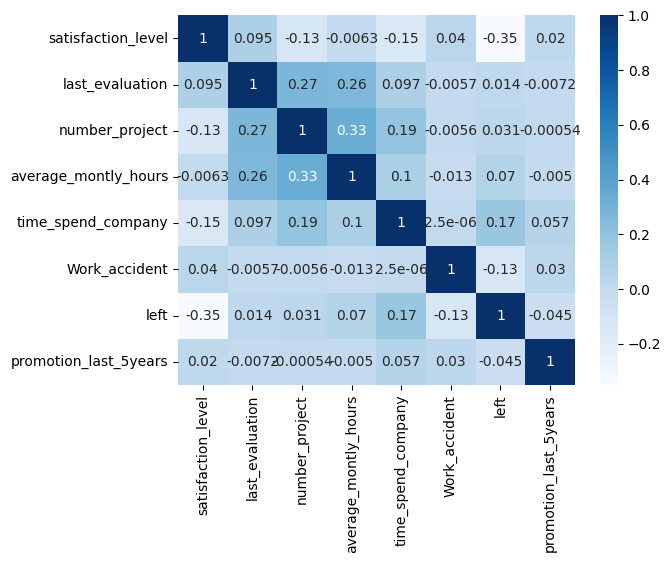

In [63]:
sns.heatmap(correlation_matrix,annot=True,cmap='Blues')
plt.show()

### From the above heatmap, we can see that the features are less correlated to the employees who left the organization. Only feature time_spend_company is slightly correlated compared to all features. There may be any other reason for the employees to leave the company

## **2.2. Draw the distribution plot of:**
###  **Employee Satisfaction (use column satisfaction_level)**
### **Employee Evaluation (use column last_evaluation)**
### **Employee Average Monthly Hours (use column average_montly_hours)**

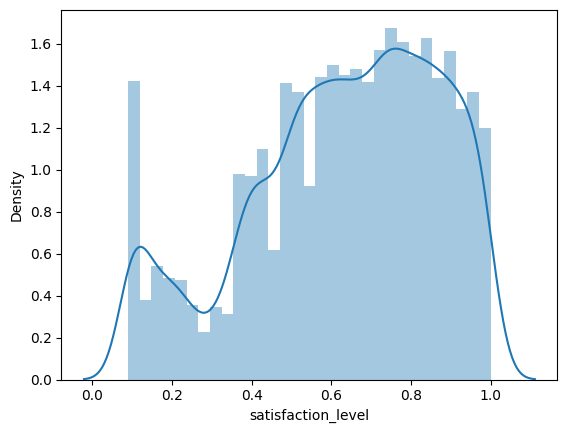

In [64]:
sns.distplot(data['satisfaction_level'])
plt.show()

### From the plot, we can infere that most of the employees have high satisfaction level which means that employees are satisfied by the company.

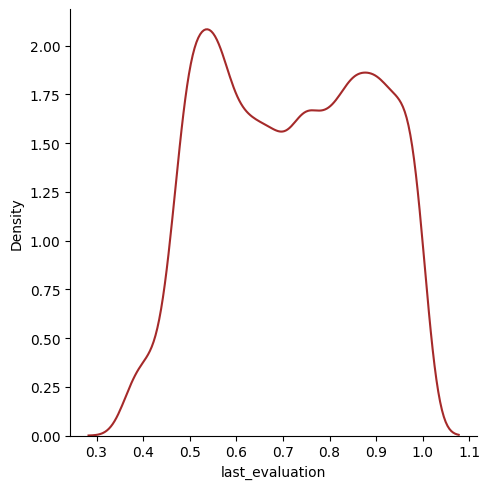

In [65]:
sns.displot(data['last_evaluation'],kind='kde',color='brown')
plt.show()

### The data is evenly distributed in the kde plot which means that most of the employees have been evaluated well in the last project.

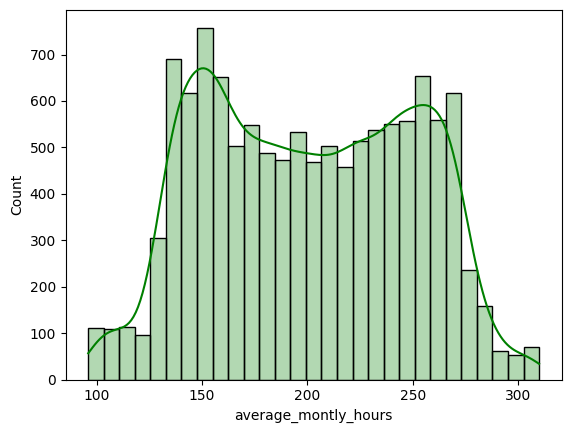

In [66]:
sns.histplot(data['average_montly_hours'],kde=True,color='green',alpha=0.3)
plt.show()

### The average monthly working hours of the employees is also balanced. Employees work around 140-270 hours per month.

## **2.3. Draw the bar plot of the employee project count of both employees who left and stayed in the organization (use column number_project and hue column left), and give your inferences from the plot.**

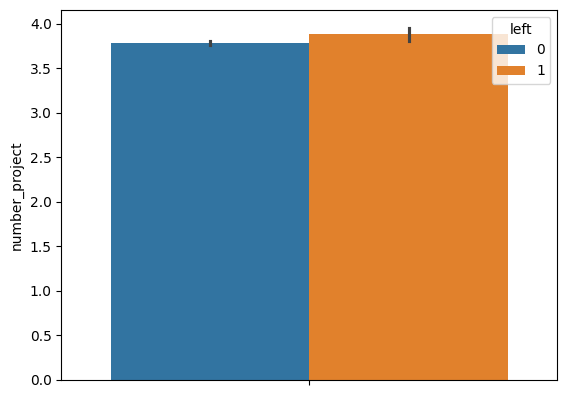

In [67]:
sns.barplot(y=data['number_project'],hue=data.left)
plt.show()

### The employees who left the company has worked slightly on more number of projects compared to the employees who has not left the company.

## **3. Perform clustering of employees who left based on their satisfaction and evaluation.**

### **3.1. Choose columns satisfaction_level, last_evaluation, and left.**

### **3.2. Do K-means clustering of employees who left the company into 3 clusters?**

### **3.3. Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.**

In [68]:
df=data.loc[data['left']==1,['satisfaction_level','last_evaluation','left']]
df.head()

,satisfaction_level,last_evaluation,left
0,0.38,0.53,1
1,0.80,0.86,1
2,0.11,0.88,1
3,0.72,0.87,1
4,0.37,0.52,1


In [69]:
df.shape

(1991, 3)

In [70]:
df.left.value_counts()

,count
left,
1,1991


In [71]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans.fit(df)

KMeans(n_clusters=3, random_state=42)

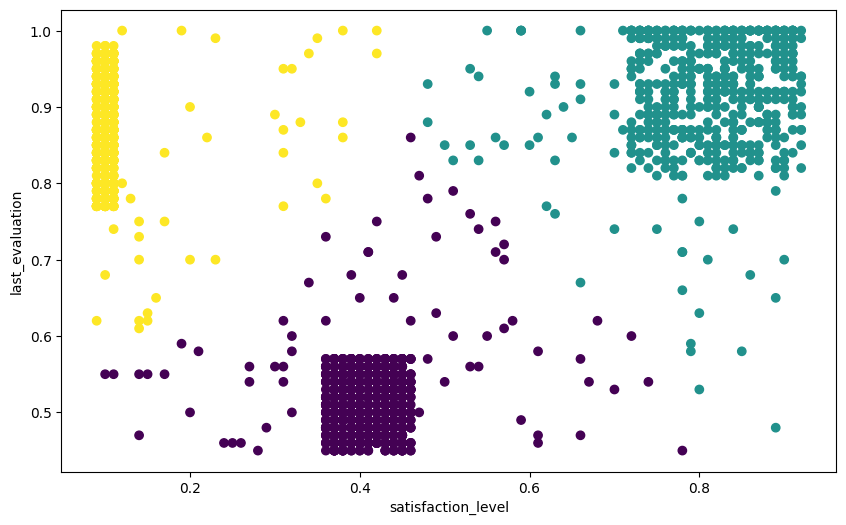

In [72]:
plt.figure(figsize=(10,6))
plt.scatter(df['satisfaction_level'],df['last_evaluation'],c=kmeans.labels_.astype(float))
plt.xlabel('satisfaction_level')
plt.ylabel('last_evaluation')
plt.show()

1.   Employees with low ratings, average satisfaction level.
2.   Employees with high ratings, high satisfaction level.
3.   Employees with high ratings, low satisfaction level.

These are the three clusters classified, based on the above rules or criteria.

## **4. Handle the left Class Imbalance using the SMOTE technique.**

  ### **4.1. Pre-process the data by converting categorical columns to numerical columns by:**

  ## **■ Separating categorical variables and numeric variables**

  ## **■ Applying get_dummies() to the categorical variables**

  ## **■ Combining categorical variables and numeric variables**

 ### **4.2. Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.**

 ### **4.3. Upsample the train dataset using the SMOTE technique from the imblearn module.**

In [73]:
data.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'sales', 'salary'],
      dtype='object')

In [74]:
data=pd.get_dummies(data,columns=['sales','salary'],dtype=int,drop_first=True)
data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,0,0,0,0,1,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,0,0,0,0,1,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0


In [75]:
data.shape

(11991, 19)

In [76]:
X=data.drop('left',axis=1)
y=data['left']

In [77]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=123,stratify=y)

In [78]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)

In [79]:
y_train_smote.shape

(15998,)

In [80]:
y_train.shape

(9592,)

In [81]:
X_train.shape

(9592, 18)

In [82]:
X_train_smote.shape

(15998, 18)

## **5. Perform 5-fold cross-validation model training and evaluate performance.**

### **5.1. Train a logistic regression model, apply a 5-fold CV, and plot the classification report.**

### **5.2. Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.**

### **5.3. Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.**

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

logistic_model=LogisticRegression()

logistic_model.fit(X_train_smote,y_train_smote)

y_pred_logistic=logistic_model.predict(X_test)

classification_report_logistic=classification_report(y_test,y_pred_logistic)
print(classification_report_logistic)

score=cross_val_score(logistic_model,X_train_smote,y_train_smote,cv=5,scoring='accuracy')
print(f"Mean accuracy of scores: {score.mean()*100:.2f}")

              precision    recall  f1-score   support

           0       0.93      0.78      0.85      2001
           1       0.38      0.69      0.49       398

    accuracy                           0.77      2399
   macro avg       0.66      0.74      0.67      2399
weighted avg       0.84      0.77      0.79      2399

Mean accuracy of scores: 82.90


In [84]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model=RandomForestClassifier()

random_forest_model.fit(X_train_smote,y_train_smote)

y_pred_rf=random_forest_model.predict(X_test)

classification_report_rf=classification_report(y_test,y_pred_rf)
print(classification_report_rf)

rf_score=cross_val_score(random_forest_model,X_train_smote,y_train_smote,cv=5,scoring='accuracy')
print(f"Mean accuracy of scores: {rf_score.mean()*100:.2f}")


              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2001
           1       0.92      0.90      0.91       398

    accuracy                           0.97      2399
   macro avg       0.95      0.94      0.95      2399
weighted avg       0.97      0.97      0.97      2399

Mean accuracy of scores: 97.46


In [85]:
from sklearn.ensemble import GradientBoostingClassifier

g_boosting_model=GradientBoostingClassifier()

g_boosting_model.fit(X_train_smote,y_train_smote)

y_pred_gbm=g_boosting_model.predict(X_test)

classification_report_gbm=classification_report(y_test,y_pred_gbm)
print(classification_report_gbm)

gbm_score=cross_val_score(g_boosting_model,X_train_smote,y_train_smote,cv=5,scoring='accuracy')
print(f"Mean accuracy of scores: {gbm_score.mean()*100:.2f}")

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      2001
           1       0.84      0.91      0.88       398

    accuracy                           0.96      2399
   macro avg       0.91      0.94      0.93      2399
weighted avg       0.96      0.96      0.96      2399

Mean accuracy of scores: 95.62


In [95]:
# from xgboost import XGBClassifier

# xg_boosting_model=XGBClassifier()

# xg_boosting_model.fit(X_train_smote,y_train_smote)

# y_pred_xgbm=xg_boosting_model.predict(X_test)

# classification_report_xgbm=classification_report(y_test,y_pred_xgbm)
# print(classification_report_xgbm)

# xgbm_score=cross_val_score(xg_boosting_model,X_train_smote,y_train_smote,cv=5,scoring='accuracy')
# print(f"Mean accuracy of scores: {xgbm_score.mean()*100:.2f}")

### **6. Identify the best model and justify the evaluation metrics used.**

 #### **6.1. Find the ROC/AUC for each model and plot the ROC curve.**

  #### **6.2. Find the confusion matrix for each of the models.**

 #### **6.3. Explain which metric needs to be used from the confusion matrix: Recall or Precision?**

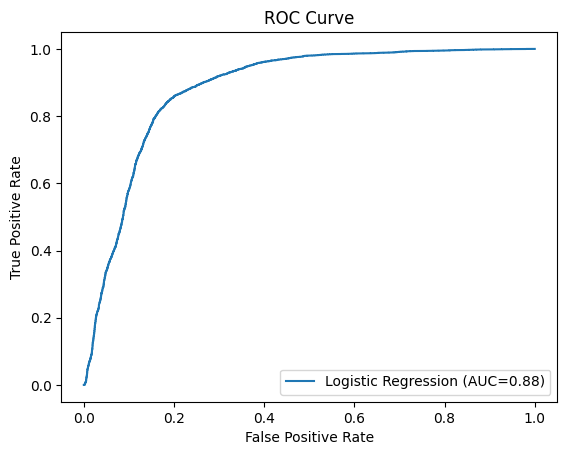

In [87]:
from sklearn.metrics import roc_curve,roc_auc_score
y_proba_logistic=logistic_model.predict_proba(X_train_smote)[:,1]

fpr,tpr,thresholds=roc_curve(y_train_smote,y_proba_logistic)

logistic_roc_auc=roc_auc_score(y_train_smote,y_proba_logistic)

plt.plot(fpr,tpr,label=f'Logistic Regression (AUC={logistic_roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

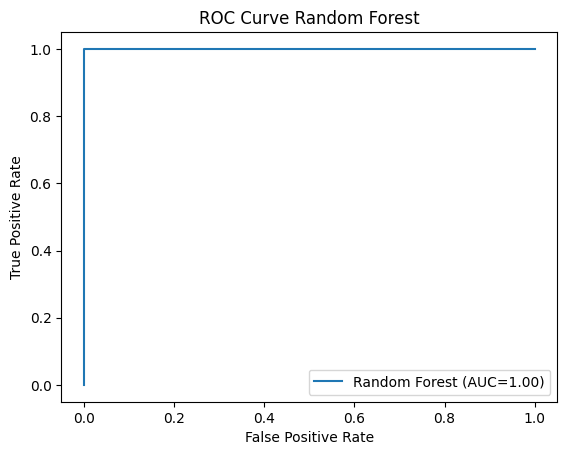

In [88]:
y_proba_rf=random_forest_model.predict_proba(X_train_smote)[:,1]

fpr1,tpr1,thresholds1=roc_curve(y_train_smote,y_proba_rf)

rf_roc_auc=roc_auc_score(y_train_smote,y_proba_rf)

plt.plot(fpr1,tpr1,label=f'Random Forest (AUC={rf_roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Random Forest')
plt.legend()
plt.show()

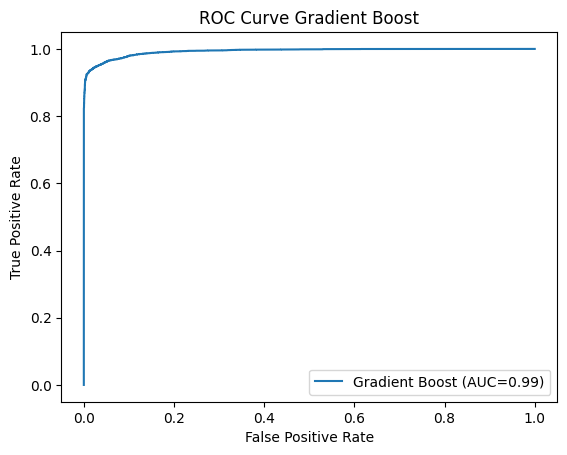

In [89]:
y_proba_gbm=g_boosting_model.predict_proba(X_train_smote)[:,1]

fpr3,tpr3,_=roc_curve(y_train_smote,y_proba_gbm)

gbm_roc_auc=roc_auc_score(y_train_smote,y_proba_gbm)

plt.plot(fpr3,tpr3,label=f'Gradient Boost (AUC={gbm_roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Gradient Boost')
plt.legend()
plt.show()

In [93]:
# y_proba_xgbm=xg_boosting_model.predict_proba(X_train_smote)[:,1]

# fpr2,tpr2,thresholds2=roc_curve(y_train_smote,y_proba_xgbm)

# xgbm_roc_auc=roc_auc_score(y_train_smote,y_proba_xgbm)

# plt.plot(fpr1,tpr1,label=f'XG Boost (AUC={xgbm_roc_auc:.2f})')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve XG Boost')
# plt.legend()
# plt.show()

Out of all three models ROC curves we can see that Random Forest has the highest score of 1 which means Random Forest model works best compared to other models

In [94]:
from sklearn.metrics import confusion_matrix
logistic_cm=confusion_matrix(y_test,y_pred_logistic)
rf_cm=confusion_matrix(y_test,y_pred_rf)
gbm_cm=confusion_matrix(y_test,y_pred_gbm)
# xgbm_cm=confusion_matrix(y_test,y_pred_xgbm)
print(f"Logistic Model:\n{logistic_cm}")
print(f"Random Forest: \n{rf_cm}")
print(f"Gradient Boosting: \n{gbm_cm}")
# print(f"XGBoost: \n{xgbm_cm}")

Logistic Model:
[[1561  440]
 [ 123  275]]
Random Forest: 
[[1969   32]
 [  38  360]]
Gradient Boosting: 
[[1934   67]
 [  34  364]]


Recall means how many actual positives are correctly predicted.

Precision means how many predicted positives are correctly predicted.

Both are very important metrics in predicting the model performance. But comparatively precision is more important in these particular case.
Although predicting correct positives is important but predicted positives should be correct one is more important.

### **7. Suggest various retention strategies for targeted employees.**

#### **7.1. Using the best model, predict the probability of employee turnover in the test data.**

#### **7.2. Based on the probability score range below, categorize the employees into four zones and suggest your thoughts on the retention strategies for each zone.**
■ Safe Zone (Green) (Score < 20%)

■ Low-Risk Zone (Yellow) (20% < Score < 60%)

■ Medium-Risk Zone (Orange) (60% < Score < 90%)

■ High-Risk Zone (Red) (Score > 90%).

In [97]:
## Random Forest

y_pred_test_rf= random_forest_model.predict_proba(X_test)[:,1]
y_pred_test_rf

array([0.06, 0.43, 0.  , ..., 0.  , 0.  , 0.08])

As per the probability score range we categorize the employees into 4 zones
Safe Zone, Low-Risk Zone, Medium-Risk Zone, High-Risk Zone.

Employees who have score less than 20 % are considered as safe zone and these category employees have very low turnover which means very low chances of leaving the company.

Employees categorized as low-risk zone are also have low chances of leaving  the company.

Employees having the score in the range of 60-90 % are under medium-risk zone. These Employees have the chances of leaving the company.

Employees having score greater than 90% are under high-risk zone. Employees with high risk zone are mostly ready to leave the company.

For employees with safe & low-risk zone are not needed to focus at present we need to focus mostly on medium-risk and high-risk zone employees. We need to give better perks and incentives to these people and give them better opportunities for higher levels according to their experience. We need to focus on the employees and need to reduce the count of employees who are planning to leave the company. Safe-zone and low-risk zone should also need not to be neglected because they can also move into medium to high risk zones. High priority should be on the employees with high risk,medium risk zones. Every department should plan the remedies according to the employees zone of leaving the company. Providing the better possible solutions to not leave the company.
